# SoilHive -- Exploratory Data Analysis

**Dataset:** Multi-source global soil observations (WoSIS · CAROB · iSDA · Global Soil Nematode DB)  
**Objective:** Characterise data quality, spatial/temporal coverage, soil variability, and ML readiness.

---
| Section | Topic |
|---------|-------|
| 1 | Dataset overview |
| 2 | Data quality analysis |
| 3 | Temporal analysis |
| 4 | Depth analysis |
| 5 | Distribution analysis (key soil variables) |
| 6 | Spatial analysis |

## Setup

In [36]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from glob import glob
from scipy import stats
import math

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = sns.color_palette('tab10')

BASE = Path('/home/agbelgaid/Documents/WORKSPACE/DataCollection/SoilHive/data/extracted')

In [3]:
def load_all_csvs(base_path):
    files = glob(str(base_path / '**/output_data_points.csv'), recursive=True)
    dfs = []
    for f in files:
        d = pd.read_csv(f)
        d['source_file'] = Path(f).parent.name
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

df = load_all_csvs(BASE)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')
df.head(3)

Loaded 2,037,633 rows × 15 columns


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,source_file
0,1,-19.4157,22.0154,CEC,soil_ECEC,0.0,20.0,0.00010,cmol/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
1,2,-19.4157,22.0154,P,soil_P_total,0.0,20.0,21.90625,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted
2,3,-19.4157,22.0154,Na,soil_ex_Na,0.0,20.0,0.00010,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted


---
## 1. Dataset Overview

In [4]:
n_rows, n_cols = df.shape
n_locations   = df[['lat', 'lon']].drop_duplicates().shape[0]
n_properties  = df['property'].nunique()
n_sources     = df['data_source'].nunique()

print('=' * 50)
print(f'  Total observations  : {n_rows:>12,}')
print(f'  Columns             : {n_cols:>12}')
print(f'  Unique locations    : {n_locations:>12,}')
print(f'  Soil properties     : {n_properties:>12}')
print(f'  Data sources        : {n_sources:>12}')
print('=' * 50)

  Total observations  :    2,037,633
  Columns             :           15
  Unique locations    :       56,991
  Soil properties     :           24
  Data sources        :            4


In [5]:
# Schema + dtypes + null count
schema = pd.DataFrame({
    'dtype'    : df.dtypes,
    'non_null' : df.notna().sum(),
    'null_%'   : (df.isna().mean() * 100).round(1),
    'n_unique' : df.nunique()
})
schema

,dtype,non_null,null_%,n_unique
id,int64,2037633,0.0,19994
lat,float64,2037633,0.0,55373
lon,float64,2037633,0.0,55125
property,object,2037633,0.0,24
original_name,object,2037633,0.0,73
upper_depth_cm,float64,2025313,0.6,702
lower_depth_cm,float64,2025313,0.6,785
value,float64,2036512,0.1,33941
unit,object,1630655,20.0,11
sampling_date,float64,1626004,20.2,75


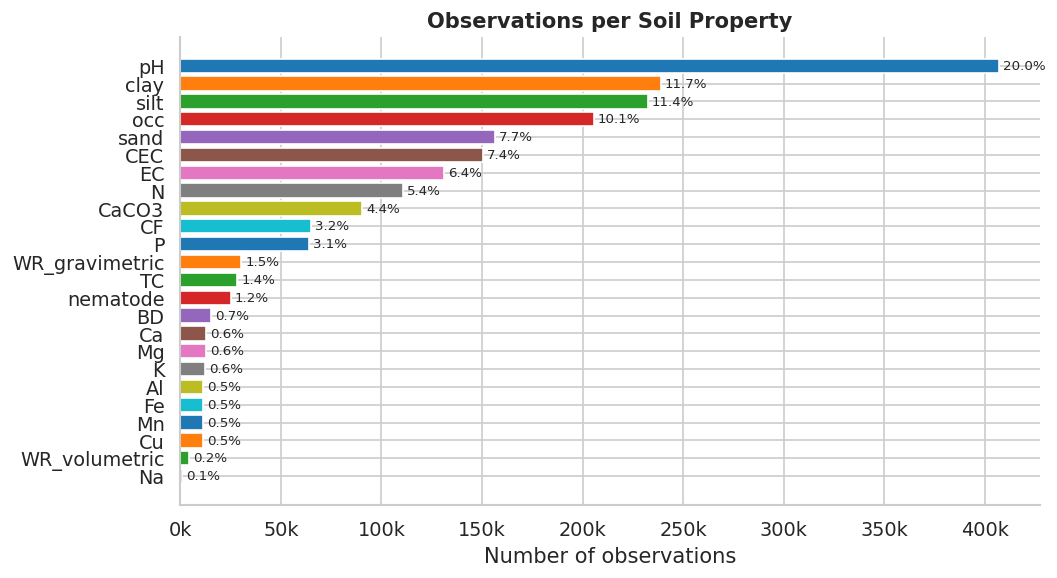

,property,n_obs,pct
0,pH,406978,20.0
1,clay,238794,11.7
2,silt,232400,11.4
3,occ,205613,10.1
4,sand,156288,7.7
5,CEC,150287,7.4
6,EC,131136,6.4
7,N,110616,5.4
8,CaCO3,90348,4.4
9,CF,65052,3.2


In [6]:
# Observations per property
prop_counts = (
    df['property']
    .value_counts()
    .rename_axis('property')
    .reset_index(name='n_obs')
)
prop_counts['pct'] = (prop_counts['n_obs'] / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(prop_counts))]
bars = ax.barh(prop_counts['property'][::-1], prop_counts['n_obs'][::-1], color=colors[::-1])
ax.set_xlabel('Number of observations')
ax.set_title('Observations per Soil Property', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for bar, pct in zip(bars, prop_counts['pct'][::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()
prop_counts

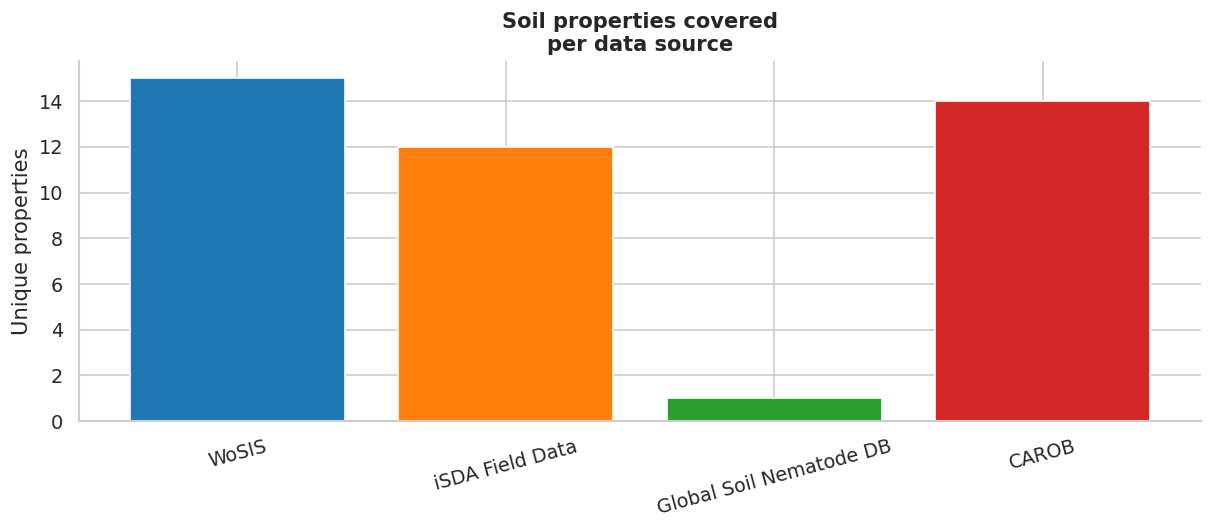

,Source,Obs,Locations,Properties,Date coverage (%),Obs (%)
0,WoSIS,1872802,53198,15,86.8,91.9
1,iSDA Field Data,122572,1368,12,0.0,6.0
2,Global Soil Nematode DB,25158,727,1,0.0,1.2
3,CAROB,17101,148,14,0.0,0.8


In [7]:
src_stats = (
    df.groupby('data_source')
    .agg(
        n_obs     =('id',  'count'),
        n_locs    =('lat', lambda x: x.drop_duplicates().count()),
        n_props   =('property', 'nunique'),
        has_date  =('sampling_date', lambda x: x.notna().mean() * 100),
    )
    .sort_values('n_obs', ascending=False)
    .reset_index()
)
src_stats['n_obs_%'] = (src_stats['n_obs'] / len(df) * 100).round(1)
src_stats['has_date'] = src_stats['has_date'].round(1)
src_stats.columns = ['Source', 'Obs', 'Locations', 'Properties', 'Date coverage (%)', 'Obs (%)']

fig = plt.figure(figsize=(11, 4))
ax = fig.add_axes([0.1, 0.15, 0.85, 0.75])

ax.bar(src_stats['Source'], src_stats['Properties'], color=PALETTE[:len(src_stats)])
ax.set_ylabel('Unique properties')
ax.set_title('Soil properties covered\nper data source', fontweight='bold')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
src_stats

**Key takeaways - Dataset Overview**
- The dataset is in **long format** (one row = one property measurement), which is memory-efficient but requires pivoting for ML.
- A small number of properties dominate the record count (e.g. pH, sand, clay, occ); rare properties like nematode or WR_gravimetric represent a tiny share.
- Data sources differ substantially in breadth (properties covered) and temporal annotation quality.

---
## 2. Data quality analysis

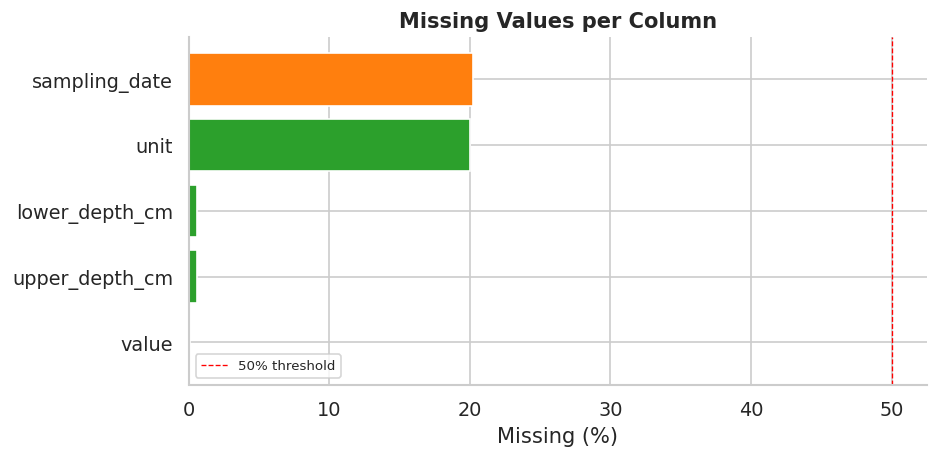

Columns with missing values:
        column  missing_%
 sampling_date  20.201332
          unit  19.973077
lower_depth_cm   0.604623
upper_depth_cm   0.604623
         value   0.055015


In [8]:
miss = df.isna().mean().mul(100).sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['column', 'missing_%']

fig, ax = plt.subplots(figsize=(8, 4))
colors_m = ['#d62728' if v > 50 else '#ff7f0e' if v > 20 else '#2ca02c'
             for v in miss_df['missing_%']]
ax.barh(miss_df['column'][::-1], miss_df['missing_%'][::-1], color=colors_m[::-1])
ax.axvline(50, color='red', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Column', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Columns with missing values:')
print(miss_df.to_string(index=False))

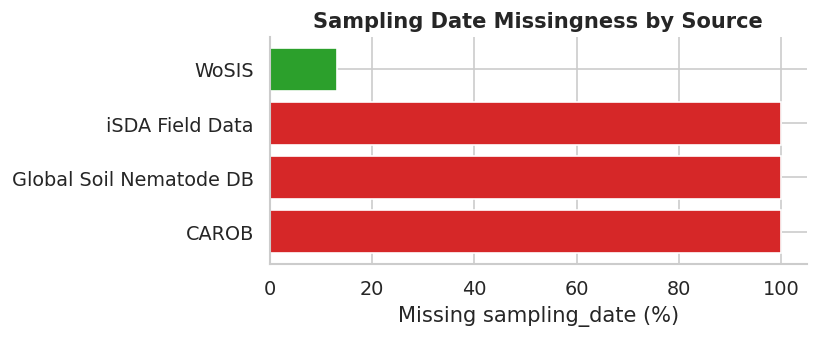

,Source,sampling_date missing (%)
0,CAROB,100.0
1,Global Soil Nematode DB,100.0
2,iSDA Field Data,100.0
3,WoSIS,13.2


In [43]:
# Missing sampling_date by source - critical for temporal analysis
date_miss_by_src = (
    df.groupby('data_source')['sampling_date']
    .apply(lambda x: x.isna().mean() * 100)
    .round(1)
    .sort_values(ascending=False)
    .reset_index()
)
date_miss_by_src.columns = ['Source', 'sampling_date missing (%)']

fig, ax = plt.subplots(figsize=(7, 3))
colors_d = ['#d62728' if v > 80 else '#ff7f0e' if v > 30 else '#2ca02c'
             for v in date_miss_by_src['sampling_date missing (%)']]
ax.barh(date_miss_by_src['Source'], date_miss_by_src['sampling_date missing (%)'],
        color=colors_d)
ax.set_xlabel('Missing sampling_date (%)')
ax.set_title('Sampling Date Missingness by Source', fontweight='bold')
plt.tight_layout()
plt.show()
date_miss_by_src

In [9]:
# ── Duplicate detection ──────────────────────────────────────────────────────
n_exact = df.duplicated().sum()

KEY = ['lat', 'lon', 'property', 'upper_depth_cm', 'lower_depth_cm', 'value']
n_functional = df.duplicated(subset=KEY).sum()

SPATIAL_KEY = ['lat', 'lon', 'property', 'upper_depth_cm', 'lower_depth_cm']
n_spatial = df.duplicated(subset=SPATIAL_KEY).sum()

print(f'Exact duplicates            : {n_exact:>8,}  ({n_exact/len(df)*100:.2f}%)')
print(f'Functional duplicates       : {n_functional:>8,}  ({n_functional/len(df)*100:.2f}%)')
print(f'Spatial co-located replicates: {n_spatial:>7,}  ({n_spatial/len(df)*100:.2f}%)')

Exact duplicates            :        1  (0.00%)
Functional duplicates       : 1,138,087  (55.85%)
Spatial co-located replicates: 1,243,951  (61.05%)


In [10]:
# ── Depth consistency validation ─────────────────────────────────────────────
depth_ok    = df['upper_depth_cm'] < df['lower_depth_cm']
depth_equal = df['upper_depth_cm'] == df['lower_depth_cm']
depth_inv   = df['upper_depth_cm'] > df['lower_depth_cm']
depth_null  = df['upper_depth_cm'].isna() | df['lower_depth_cm'].isna()

checks = pd.Series({
    'upper < lower  (valid)'  : depth_ok.sum(),
    'upper == lower (zero thickness)': depth_equal.sum(),
    'upper > lower  (inverted)': depth_inv.sum(),
    'null depth (either)': depth_null.sum(),
})
print('Depth consistency:')
for k, v in checks.items():
    pct = v / len(df) * 100
    flag = '  ✓' if 'valid' in k else '  ⚠' if v > 0 else '  ✓'
    print(f'  {k:<35}: {v:>8,}  ({pct:.2f}%){flag}')

Depth consistency:
  upper < lower  (valid)             : 2,025,313  (99.40%)  ✓
  upper == lower (zero thickness)    :        0  (0.00%)  ✓
  upper > lower  (inverted)          :        0  (0.00%)  ✓
  null depth (either)                :   12,320  (0.60%)  ⚠


- `sampling_date` is the most critical missing field (~52% overall); missingness is highly source-dependent.
- `unit` is missing for ~26% of records - primarily nematode counts which have no standard unit.

---
## 3. Temporal Analysis

In [11]:
df_dated = df.dropna(subset=['sampling_date']).copy()
df_dated['year'] = df_dated['sampling_date'].astype(int)

n_dated = len(df_dated)
pct_dated = n_dated / len(df) * 100

print(f'Records with sampling date : {n_dated:>8,}  ({pct_dated:.1f}%)')
print(f'Records without            : {len(df)-n_dated:>8,}  ({100-pct_dated:.1f}%)')
print(f'Year range                 : {df_dated["year"].min()} - {df_dated["year"].max()}')

Records with sampling date : 1,626,004  (79.8%)
Records without            :  411,629  (20.2%)
Year range                 : 1920 - 2015


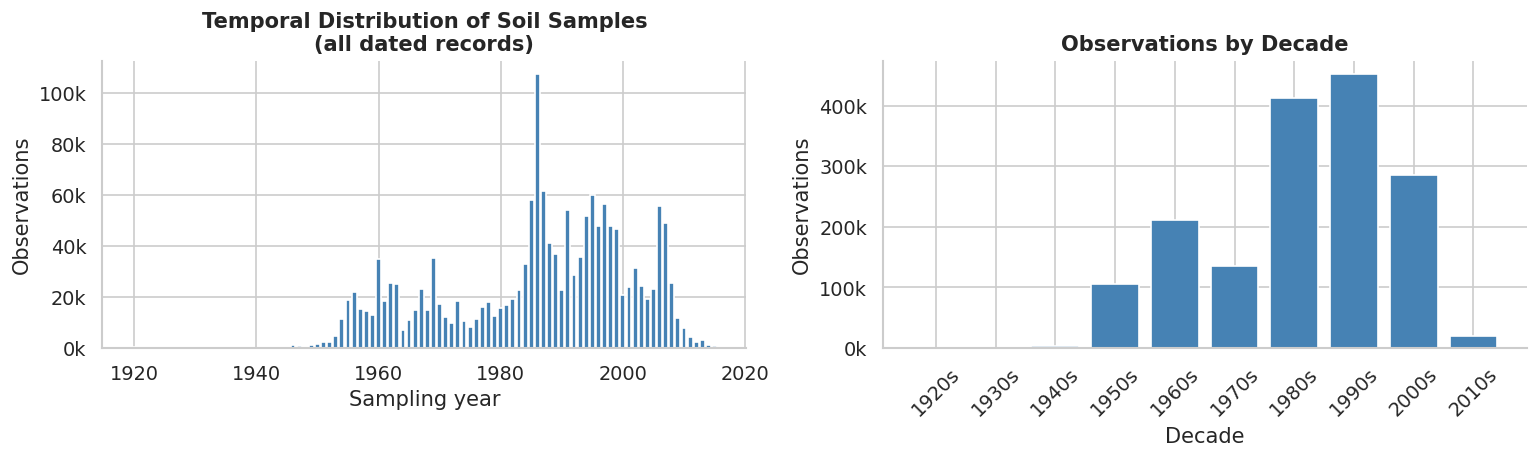

In [12]:
year_counts = df_dated['year'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full histogram
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', width=0.8)
axes[0].set_xlabel('Sampling year')
axes[0].set_ylabel('Observations')
axes[0].set_title('Temporal Distribution of Soil Samples\n(all dated records)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Decade aggregation
df_dated['decade'] = (df_dated['year'] // 10) * 10
decade_counts = df_dated['decade'].value_counts().sort_index()
axes[1].bar([str(d) + 's' for d in decade_counts.index], decade_counts.values,
            color='steelblue')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Observations')
axes[1].set_title('Observations by Decade', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

In [49]:
src_temporal = (
    df_dated.groupby('data_source')['year']
    .agg(['min', 'max', 'count', 'median'])
    .rename(columns={'min': 'first_year', 'max': 'last_year',
                     'count': 'n_obs', 'median': 'median_year'})
    .sort_values('n_obs', ascending=False)
)
src_temporal['median_year'] = src_temporal['median_year'].astype(int)
src_temporal

,first_year,last_year,n_obs,median_year
data_source,,,,
WoSIS,1920,2015,1626004,1988


In [51]:
# Temporal gap analysis: years with zero or very few records
all_years = pd.Series(range(df_dated['year'].min(), df_dated['year'].max() + 1),
                      name='year')
year_full = all_years.to_frame().merge(year_counts.rename('count').reset_index(),
                                       on='year', how='left').fillna(0)
gap_years = year_full[year_full['count'] == 0]['year'].tolist()

sparse_threshold = year_full['count'].quantile(0.10)
sparse_years = year_full[year_full['count'] <= sparse_threshold]['year'].tolist()

print(f'Years with zero observations : {len(gap_years)} years')
if gap_years:
    print(f'  → {gap_years}')
print(f'Sparse years (bottom 10%)   : {len(sparse_years)} years')
print(f'\nPeak decade: {decade_counts.idxmax()}s  ({decade_counts.max():,} obs)')
print(f'Post-2000 observations      : {(df_dated["year"] >= 2000).sum():,}  '
      f'({(df_dated["year"] >= 2000).mean()*100:.1f}%)')

Years with zero observations : 21 years
  → [1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1932, 1933, 1934, 1935, 1936, 1937, 1939, 1941, 1942, 1943, 1944]
Sparse years (bottom 10%)   : 21 years

Peak decade: 1990s  (451,917 obs)
Post-2000 observations      : 304,772  (18.7%)


**Key takeaways - Temporal Analysis**
- Records are heavily biased toward the **1970s-1980s**; post-2000 coverage is sparse.
- ~52% of records have no sampling date - any time-series or temporal trend analysis is limited.
- For ML, the temporal bias means a model trained on this data may not generalise to current soil conditions without reweighting or augmentation with modern surveys.

---
## 4. Depth Analysis

In [52]:
df_depth = df.dropna(subset=['upper_depth_cm', 'lower_depth_cm']).copy()
df_depth['thickness_cm'] = df_depth['lower_depth_cm'] - df_depth['upper_depth_cm']

print('Depth statistics (cm):')
print(df_depth[['upper_depth_cm', 'lower_depth_cm', 'thickness_cm']]
      .describe().round(1).to_string())

Depth statistics (cm):
       upper_depth_cm  lower_depth_cm  thickness_cm
count       2025313.0       2025313.0     2025313.0
mean             34.3            61.7          27.4
std              54.0            64.9          22.1
min               0.0             1.0           1.0
25%               0.0            20.0          15.0
50%              20.0            45.0          22.0
75%              50.0            86.0          30.0
max            2800.0          2900.0        1030.0


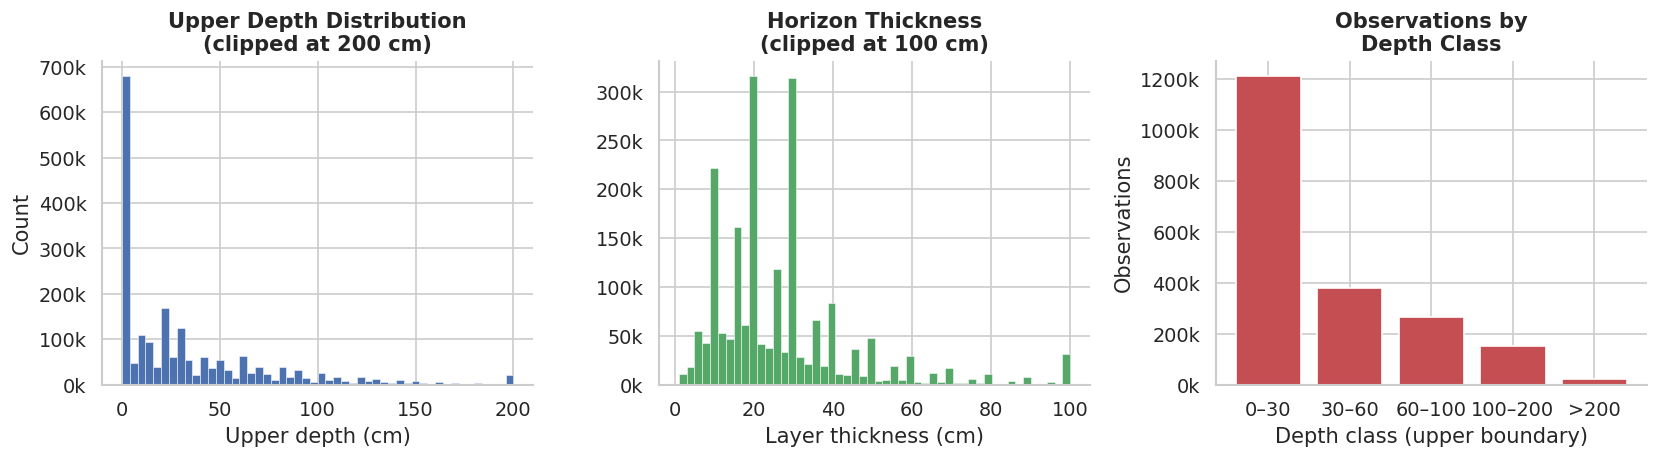

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Upper depth distribution (clipped at 200 cm for readability)
upper_clip = df_depth['upper_depth_cm'].clip(upper=200)
axes[0].hist(upper_clip, bins=50, color='#4C72B0', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Upper depth (cm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Upper Depth Distribution\n(clipped at 200 cm)', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Layer thickness
thick_clip = df_depth['thickness_cm'].clip(upper=100)
axes[1].hist(thick_clip, bins=50, color='#55A868', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Layer thickness (cm)')
axes[1].set_title('Horizon Thickness\n(clipped at 100 cm)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Depth class counts
bins_labels  = [0, 30, 60, 100, 200, np.inf]
bin_names    = ['0-30', '30-60', '60-100', '100-200', '>200']
df_depth['depth_class'] = pd.cut(
    df_depth['upper_depth_cm'], bins=bins_labels, labels=bin_names, right=False
)
dc = df_depth['depth_class'].value_counts().reindex(bin_names)
axes[2].bar(dc.index, dc.values, color='#C44E52')
axes[2].set_xlabel('Depth class (upper boundary)')
axes[2].set_ylabel('Observations')
axes[2].set_title('Observations by\nDepth Class', fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

plt.tight_layout()
plt.show()

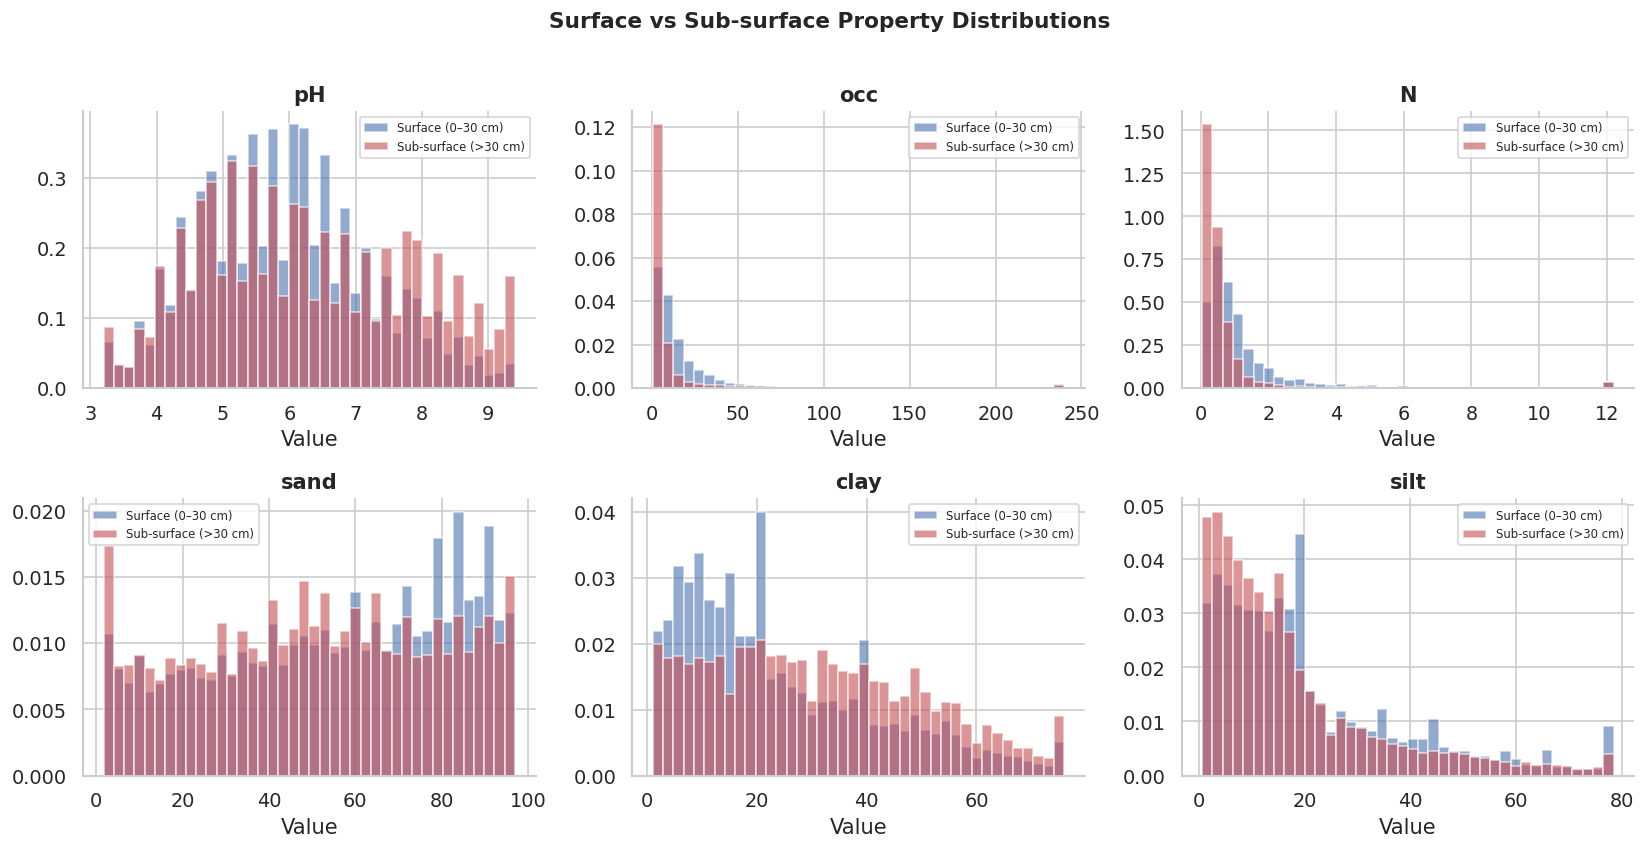

In [ ]:
# Surface (0-30 cm) vs sub-surface properties
surface_props = ['pH', 'occ', 'N', 'sand', 'clay', 'silt']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, prop in enumerate(surface_props):
    sub = df_depth[df_depth['property'] == prop].copy()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    sub['layer'] = np.where(sub['upper_depth_cm'] < 30, 'Surface (0-30)', 'Sub-surface (>30)')
    p1 = sub[sub['upper_depth_cm'] < 30]['value'].clip(
        *sub['value'].quantile([0.01, 0.99]))
    p2 = sub[sub['upper_depth_cm'] >= 30]['value'].clip(
        *sub['value'].quantile([0.01, 0.99]))

    axes[i].hist(p1, bins=40, alpha=0.6, label='Surface (0-30 cm)',
                 color='#4C72B0', density=True)
    axes[i].hist(p2, bins=40, alpha=0.6, label='Sub-surface (>30 cm)',
                 color='#C44E52', density=True)
    axes[i].set_title(prop, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('Value')

plt.suptitle('Surface vs Sub-surface Property Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

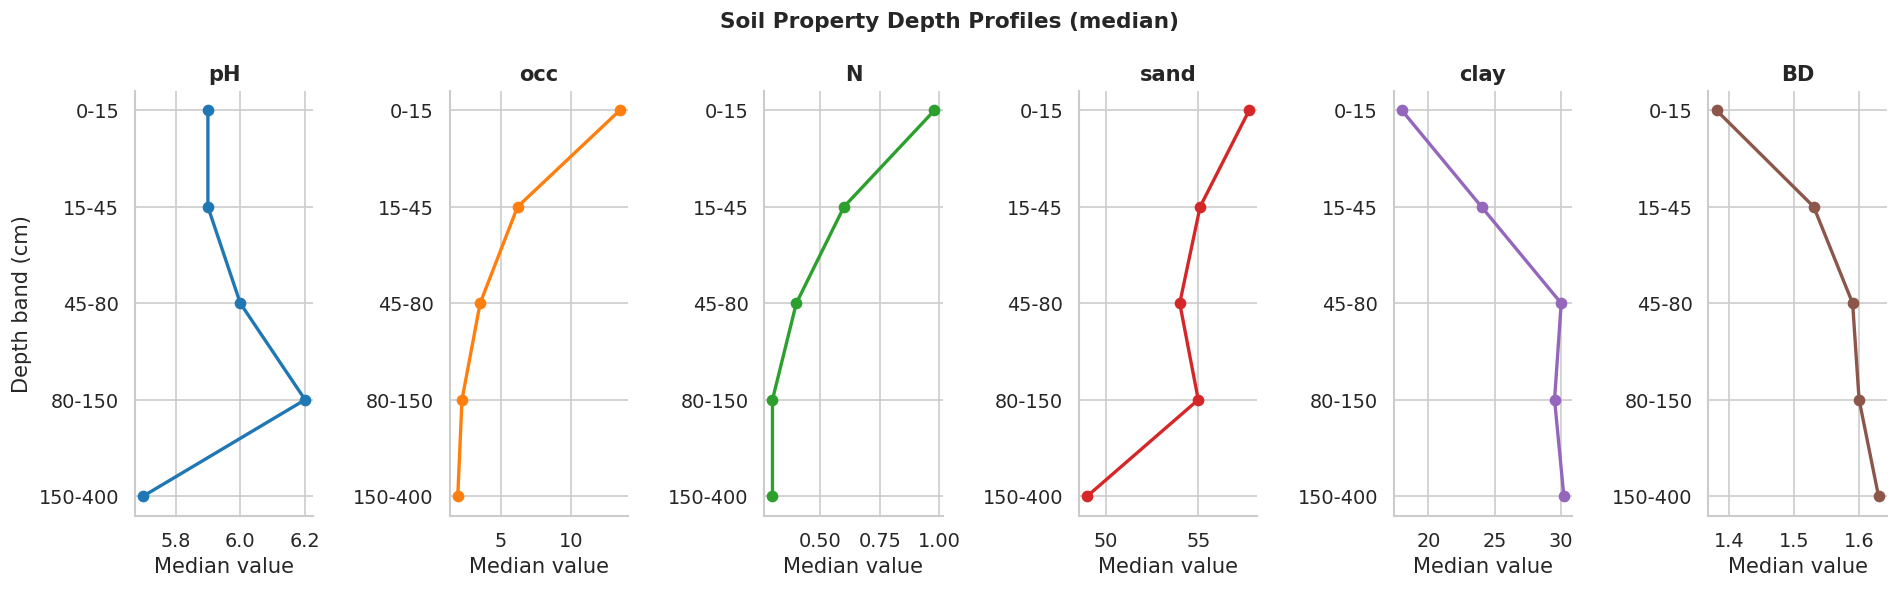

In [54]:
# Median property value per depth class (depth profile)
DEPTH_PROPS = ['pH', 'occ', 'N', 'sand', 'clay', 'BD']
sub_depth = df_depth[df_depth['property'].isin(DEPTH_PROPS)].copy()
sub_depth['mid_depth'] = (sub_depth['upper_depth_cm'] + sub_depth['lower_depth_cm']) / 2
sub_depth['depth_band'] = pd.cut(
    sub_depth['mid_depth'],
    bins=[0, 15, 45, 80, 150, 400],
    labels=['0-15', '15-45', '45-80', '80-150', '150-400']
)

profile = (
    sub_depth.groupby(['depth_band', 'property'])['value']
    .median()
    .reset_index()
)

fig, axes = plt.subplots(1, len(DEPTH_PROPS), figsize=(16, 5), sharey=False)
depth_order = ['0-15', '15-45', '45-80', '80-150', '150-400']

for i, prop in enumerate(DEPTH_PROPS):
    sub = profile[profile['property'] == prop]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].plot(sub['value'], sub['depth_band'].astype(str), 'o-', color=PALETTE[i], linewidth=2)
    # Invert y so surface is at top
    axes[i].set_yticks(range(len(depth_order)))
    axes[i].set_yticklabels(depth_order)
    axes[i].invert_yaxis()
    axes[i].set_title(prop, fontweight='bold')
    axes[i].set_xlabel('Median value')
    if i == 0:
        axes[i].set_ylabel('Depth band (cm)')

plt.suptitle('Soil Property Depth Profiles (median)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key takeaways - Depth Analysis**
- The majority of observations are **surface samples (0-30 cm)**, which aligns with agronomic priorities.
- Organic carbon (occ) and nitrogen (N) decrease sharply with depth  a well-known pedological pattern.
- pH tends to be more stable with depth, though acidic topsoils are common under forest cover.
- For ML, depth must be treated as a feature, not just a filter; depth-aware models will outperform those using only surface data.

---
## 5. Distribution Analysis  Key Soil Variables

In [14]:
def describe_property(df, prop, clip_pct=(0.01, 0.99)):
    """Return clipped series + summary statistics for a property."""
    vals = df[df['property'] == prop]['value'].dropna()
    lo, hi = vals.quantile(clip_pct[0]), vals.quantile(clip_pct[1])
    clipped = vals.clip(lo, hi)
    skew = stats.skew(clipped)
    kurt = stats.kurtosis(clipped)
    summary = {
        'n': len(vals), 'mean': vals.mean(), 'median': vals.median(),
        'std': vals.std(), 'min': vals.min(), 'max': vals.max(),
        'p1': vals.quantile(0.01), 'p99': vals.quantile(0.99),
        'skewness': skew, 'kurtosis': kurt,
        'n_iqr_outliers': ((vals < vals.quantile(0.25) - 1.5*(vals.quantile(0.75)-vals.quantile(0.25))) |
                           (vals > vals.quantile(0.75) + 1.5*(vals.quantile(0.75)-vals.quantile(0.25)))).sum()
    }
    return clipped, summary

TARGET_PROPS = ['pH', 'N', 'occ', 'EC', 'sand', 'clay', 'silt']
print('Properties available:', df['property'].unique().tolist())

Properties available: ['CEC', 'P', 'Na', 'pH', 'Mg', 'K', 'N', 'occ', 'Ca', 'TC', 'sand', 'silt', 'EC', 'clay', 'CaCO3', 'BD', 'CF', 'WR_gravimetric', 'WR_volumetric', 'Al', 'Cu', 'Fe', 'Mn', 'nematode']


In [26]:
df.columns

Index(['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm',
       'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license',
       'h3_index', 'publication_date', 'data_source', 'source_file'],
      dtype='object')

In [27]:
import geopandas as gpd

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)

gdf = gpd.sjoin(
    gdf,
    world[["geometry", "ADMIN"]],
    how="left",
    predicate="within"
)

df = gdf.rename(columns={"ADMIN": "country"}).drop(columns=["geometry", "index_right"])
df

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,source_file,country
0,1,-19.4157,22.0154,CEC,soil_ECEC,0.0,20.0,0.000100,cmol/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted,Botswana
1,2,-19.4157,22.0154,P,soil_P_total,0.0,20.0,21.906250,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted,Botswana
2,3,-19.4157,22.0154,Na,soil_ex_Na,0.0,20.0,0.000100,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted,Botswana
3,4,-19.4157,22.0154,pH,soil_pH,0.0,20.0,5.230469,NaN,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted,Botswana
4,5,-19.4157,22.0154,Mg,soil_ex_Mg,0.0,20.0,0.203125,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2024-01-01,CAROB,extracted,Botswana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2037628,205,-19.3410,22.0368,Mn,manganese_extractable,0.0,20.0,47.609000,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw,Botswana
2037629,206,-19.3410,22.0368,N,nitrogen_total,0.0,20.0,0.590000,g/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw,Botswana
2037630,207,-19.3410,22.0368,pH,ph_h20,0.0,20.0,6.486000,NaN,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw,Botswana
2037631,208,-19.3410,22.0368,K,potassium_extractable,0.0,20.0,104.765000,mg/kg,NaN,CC BY 4.0,83974cfffffffff,2023-01-01,iSDA Field Data,2d7uogpw,Botswana


In [38]:
df_pivot_base = df[[
    "lat", "lon", "country", "property", "value", "sampling_date"
]].dropna()

print(f"Shape df_pivot_base {df_pivot_base.shape}")

df_wide = df_pivot_base.pivot_table(
    index=["lat", "lon", "country"],
    columns="property",
    values="value",
    aggfunc="mean"
).reset_index()
df_wide = df_wide.rename_axis(None, axis=1)
print(f"Shape df_wide {df_wide.shape}")


Shape df_pivot_base (1608768, 6)
Shape df_wide (45241, 18)


Filtrage pour une meilleure lisiblité

In [56]:
valid_props = [
    p for p in df_wide.columns
    if p not in ["lat", "lon", "country"]
    and df_wide[p].notna().mean() > 0.2
]
properties = valid_props[:7]  

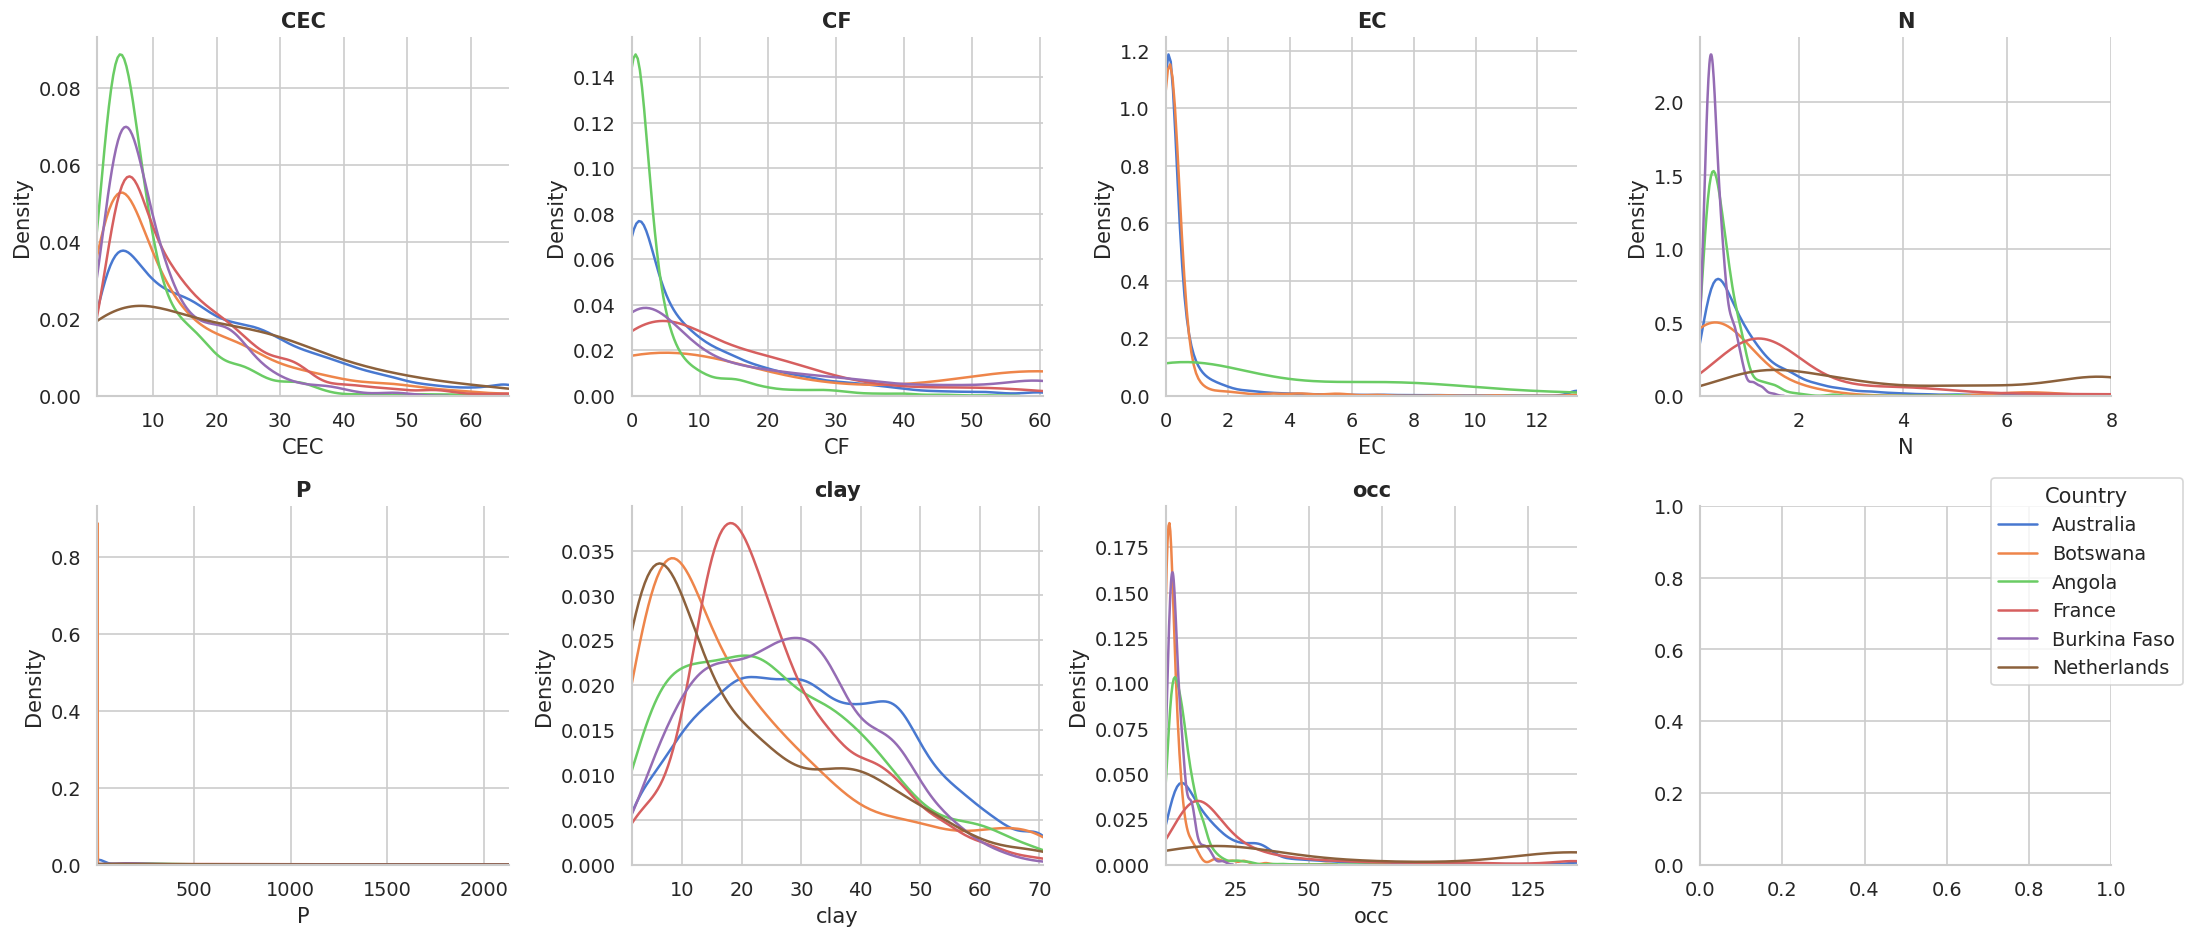

In [57]:
top_countries = (
    df_wide["country"]
    .value_counts()
    .head(10)
    .index
)

df_plot = df_wide[df_wide["country"].isin(top_countries)]
top_countries = df_wide["country"].value_counts().head(6).index
df_plot = df_wide[df_wide["country"].isin(top_countries)]
ncols = 4
nrows = math.ceil(len(properties) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, prop in enumerate(properties):
    
    ax = axes[i]
    
    data = df_plot[prop].dropna()
    
    if len(data) < 50:
        ax.set_title(f"{prop} (too sparse)")
        continue
    
    q_low  = data.quantile(0.01)
    q_high = data.quantile(0.99)
    
    for country in df_plot["country"].unique():
        
        subset = df_plot[df_plot["country"] == country][prop].dropna()
        
        if len(subset) < 20:
            continue
        
        subset = subset.clip(q_low, q_high)
        
        sns.kdeplot(subset, ax=ax, label=country)
    
    ax.set_xlim(q_low, q_high)
    ax.set_title(prop, fontweight="bold")
    ax.set_xlabel(prop)
    ax.set_ylabel("Density")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Country", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

In [19]:
# ── Aggregate summary table ──────────────────────────────────────────────
KEY_PROPS = [p for p in ['pH', 'N', 'occ', 'EC', 'sand', 'clay', 'silt', 'CEC', 'BD', 'CaCO3']
             if p in df['property'].values]

rows = []
for p in KEY_PROPS:
    _, s = describe_property(df, p)
    rows.append({'Property': p, **s})

summary_tbl = pd.DataFrame(rows).set_index('Property')
summary_tbl = summary_tbl[['n', 'mean', 'median', 'std', 'skewness', 'n_iqr_outliers']]
summary_tbl.columns = ['N obs', 'Mean', 'Median', 'Std', 'Skewness', 'IQR outliers']
summary_tbl[['Mean', 'Median', 'Std', 'Skewness']] = summary_tbl[
    ['Mean', 'Median', 'Std', 'Skewness']].round(3)
summary_tbl

,N obs,Mean,Median,Std,Skewness,IQR outliers
Property,,,,,,
pH,406978,6.081,6.00,1.451,0.298,1037
N,110616,1.194,0.61,2.359,4.357,10644
occ,205613,17.774,7.00,43.238,4.888,20753
EC,131136,0.799,0.10,3.191,4.926,20131
sand,156288,53.289,55.00,27.724,-0.209,0
clay,238794,26.929,22.00,18.791,0.669,726
silt,232400,19.835,15.00,17.657,1.434,14812
CEC,150287,14.458,9.20,14.135,1.562,7937
BD,15106,1.421,1.56,0.426,-1.420,1106


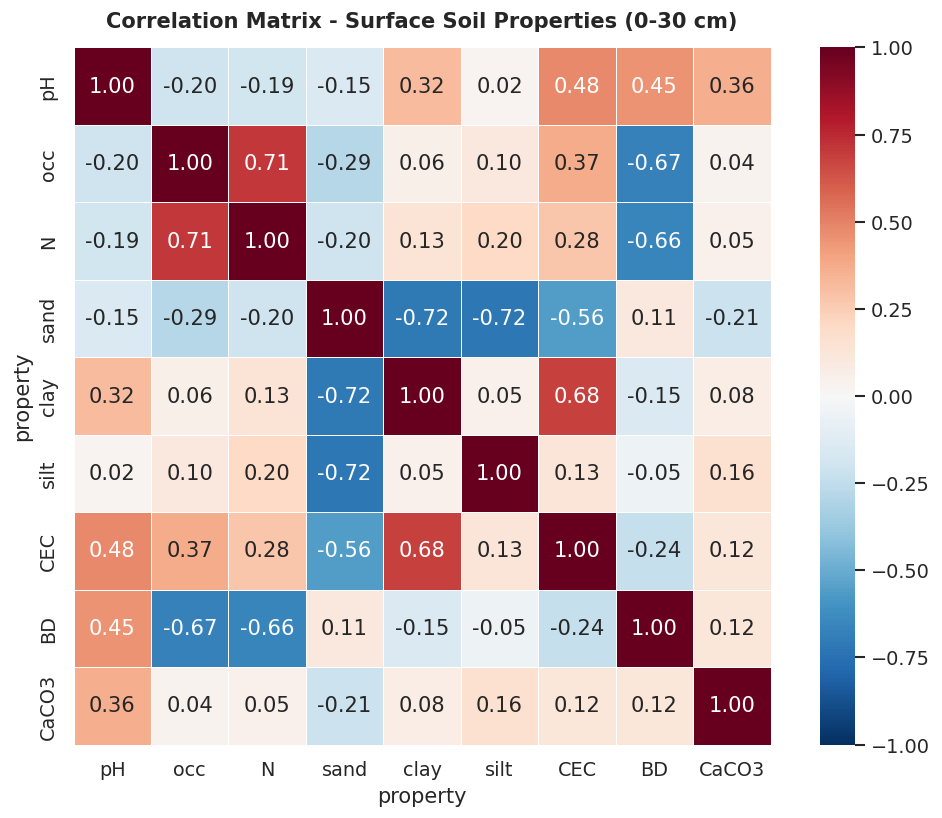

Correlation based on 97,235 co-located surface measurements


In [ ]:
# ── Correlation matrix (co-located, surface 0-30 cm) ─────────────────────
CORR_PROPS = [p for p in ['pH', 'occ', 'N', 'sand', 'clay', 'silt', 'CEC', 'BD', 'CaCO3']
              if p in df['property'].values]

# Pivot: one row per (lat, lon, depth), one col per property
surface = df[
    (df['property'].isin(CORR_PROPS)) &
    (df['upper_depth_cm'].fillna(999) < 30)
][['lat', 'lon', 'upper_depth_cm', 'property', 'value']].copy()

pivot = (
    surface
    .groupby(['lat', 'lon', 'upper_depth_cm', 'property'])['value']
    .median()
    .unstack('property')
    .reset_index()
)
corr_mat = pivot[CORR_PROPS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix - Surface Soil Properties (0-30 cm)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.show()
print(f'Correlation based on {len(pivot):,} co-located surface measurements')

**Key takeaways - Distribution Analysis**
- **pH** is approximately normally distributed in the 5-8 range; global dataset covers both acidic and alkaline soils.
- **OC and N** are heavily right-skewed - log-transformation is required before ML modelling.
- **Sand** shows a bimodal-ish pattern reflecting coarse-textured and fine-textured soil populations.
- **EC** is strongly right-skewed with most soils non-saline; extreme values indicate salt-affected soils.
- **Clay-sand anti-correlation** is strong and expected; any model must respect the texture constraint (sand + clay + silt ≈ 100).
- **CEC correlates positively with clay and OC** - consistent with known soil chemistry.

---
## 6. Spatial Analysis

In [ ]:
# Unique locations
locations = (
    df[['lat', 'lon', 'data_source']]
    .drop_duplicates(subset=['lat', 'lon'])
    .reset_index(drop=True)
)

print(f'Unique locations: {len(locations):,}')
print(f'Lat range: {locations["lat"].min():.2f} - {locations["lat"].max():.2f}')
print(f'Lon range: {locations["lon"].min():.2f} - {locations["lon"].max():.2f}')

Unique locations: 56,991
Lat range: -43.52 – 59.54
Lon range: -68.27 – 153.61


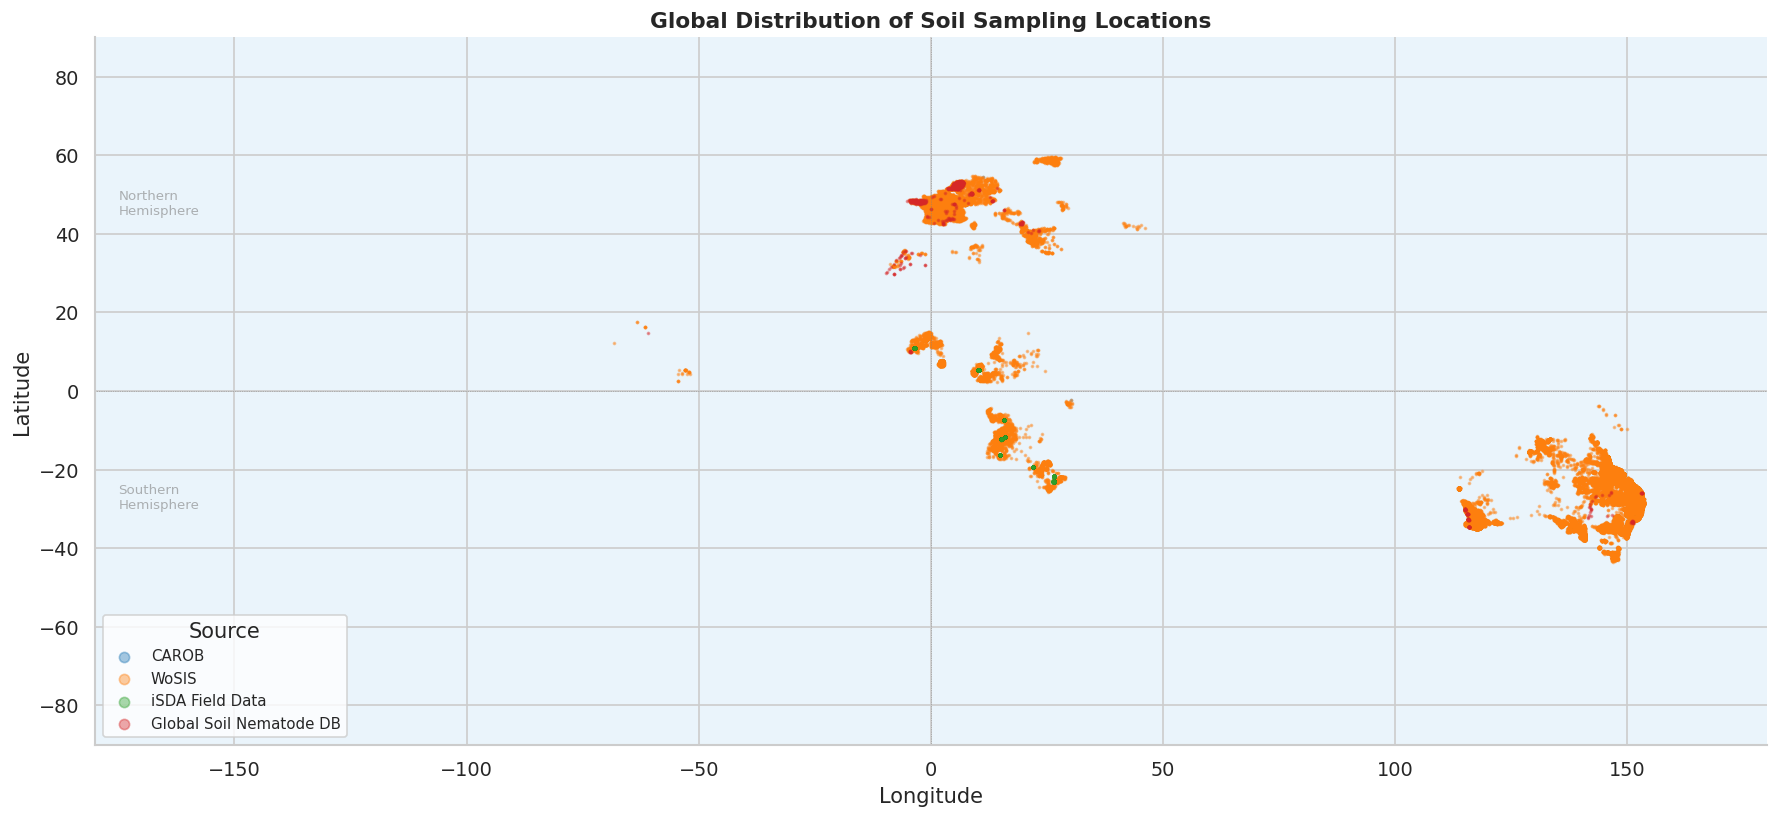

In [22]:
# Global dot map coloured by data source
sources_list = locations['data_source'].unique()
src_colors   = {s: PALETTE[i % len(PALETTE)] for i, s in enumerate(sources_list)}

fig, ax = plt.subplots(figsize=(15, 7))
ax.set_facecolor('#EAF4FB')

for src in sources_list:
    sub = locations[locations['data_source'] == src]
    ax.scatter(sub['lon'], sub['lat'], s=1.5, alpha=0.4,
               color=src_colors[src], label=src, rasterized=True)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Global Distribution of Soil Sampling Locations', fontweight='bold', fontsize=13)
ax.axhline(0, color='gray', linewidth=0.4, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.4, linestyle=':')
ax.legend(loc='lower left', markerscale=5, fontsize=9,
          framealpha=0.8, title='Source')

# Hemisphere annotations
ax.text(-175, 45, 'Northern\nHemisphere', color='gray', fontsize=8, alpha=0.6)
ax.text(-175, -30, 'Southern\nHemisphere', color='gray', fontsize=8, alpha=0.6)

plt.tight_layout()
plt.show()

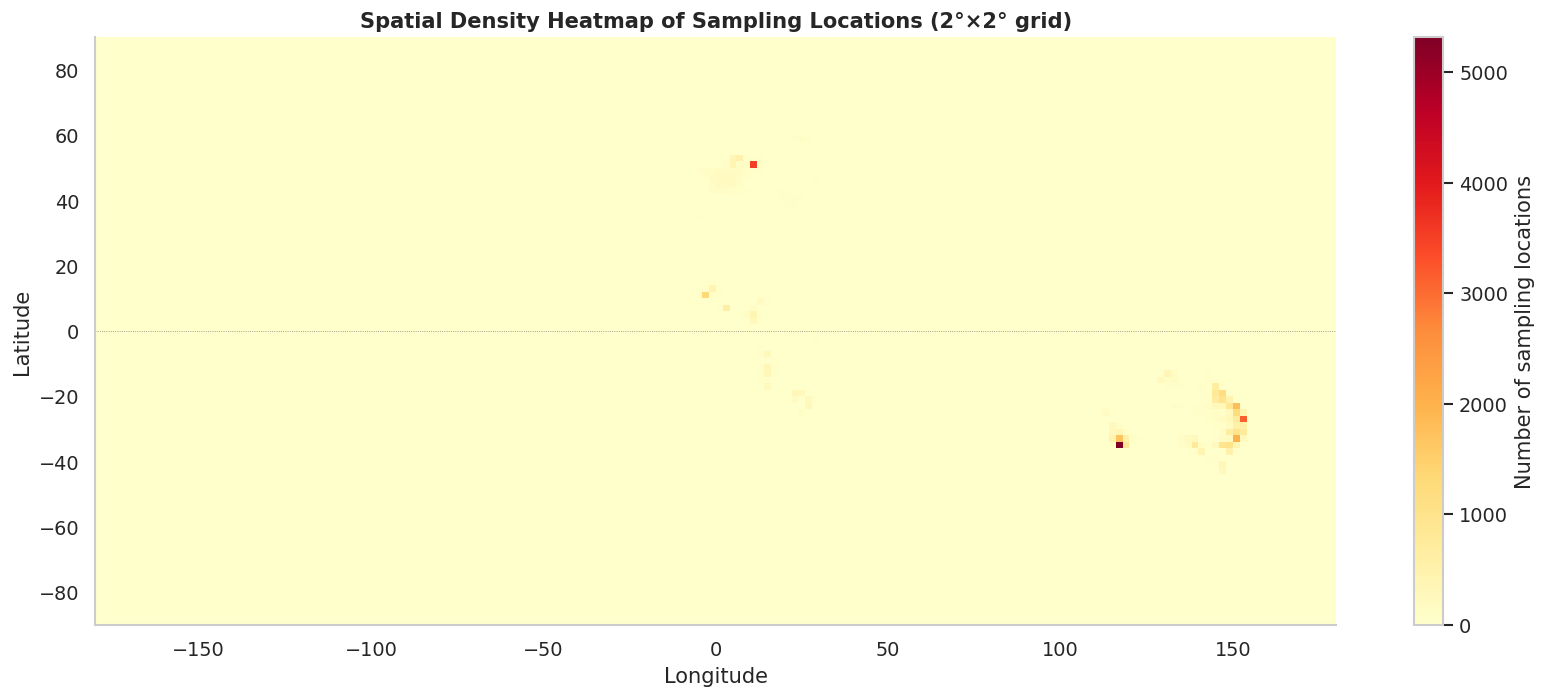

In [23]:
# Spatial density heatmap using 2D histogram
fig, ax = plt.subplots(figsize=(14, 6))
h = ax.hist2d(
    locations['lon'], locations['lat'],
    bins=[180, 90],
    range=[[-180, 180], [-90, 90]],
    cmap='YlOrRd'
)
plt.colorbar(h[3], ax=ax, label='Number of sampling locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Density Heatmap of Sampling Locations (2°×2° grid)', fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
plt.tight_layout()
plt.show()

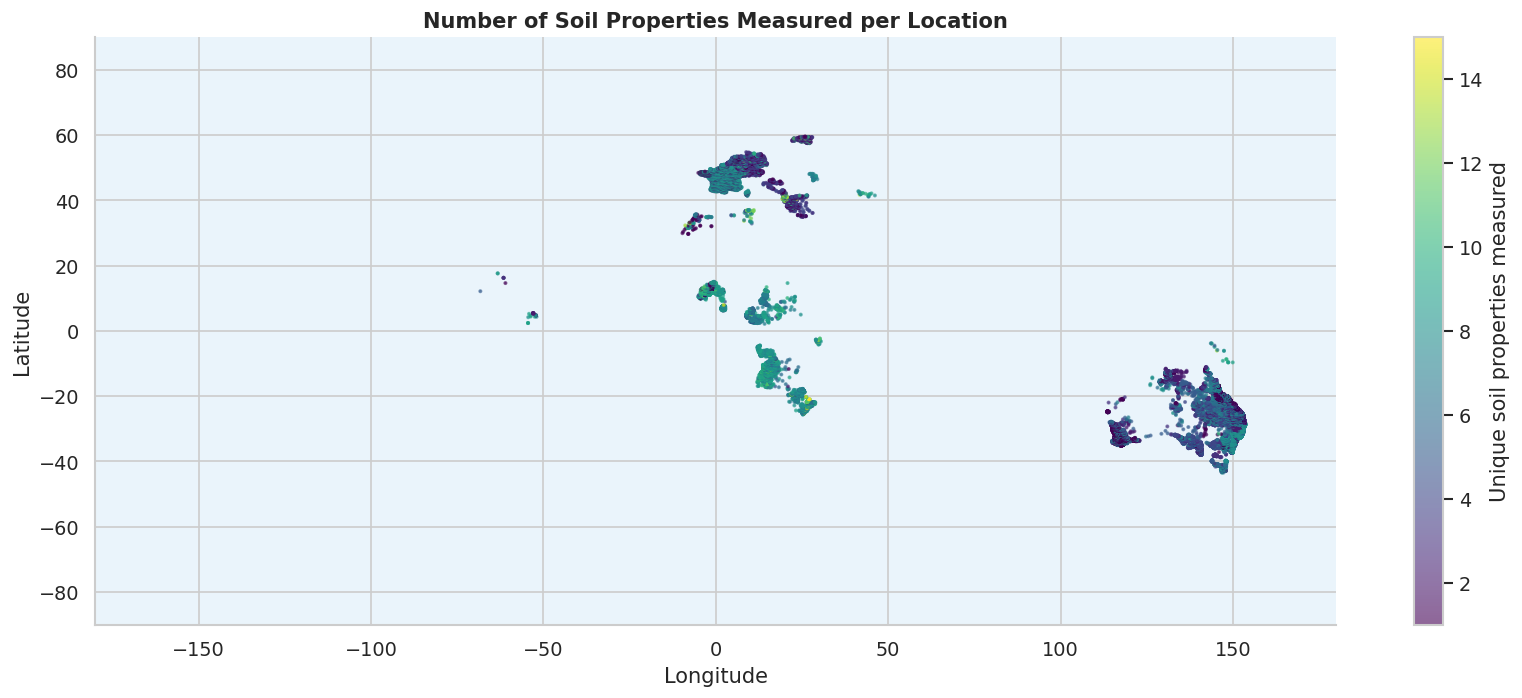

Properties per location:
count    56991.0
mean         4.4
std          2.9
min          1.0
25%          2.0
50%          4.0
75%          7.0
max         15.0


In [24]:
# Property coverage: how many unique properties measured per location
props_per_loc = (
    df.groupby(['lat', 'lon'])['property']
    .nunique()
    .reset_index(name='n_properties')
)

fig, ax = plt.subplots(figsize=(14, 6))
sc = ax.scatter(
    props_per_loc['lon'], props_per_loc['lat'],
    c=props_per_loc['n_properties'], cmap='viridis',
    s=2, alpha=0.6, rasterized=True
)
plt.colorbar(sc, ax=ax, label='Unique soil properties measured')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_facecolor('#EAF4FB')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Number of Soil Properties Measured per Location', fontweight='bold')
plt.tight_layout()
plt.show()

print('Properties per location:')
print(props_per_loc['n_properties'].describe().round(1).to_string())

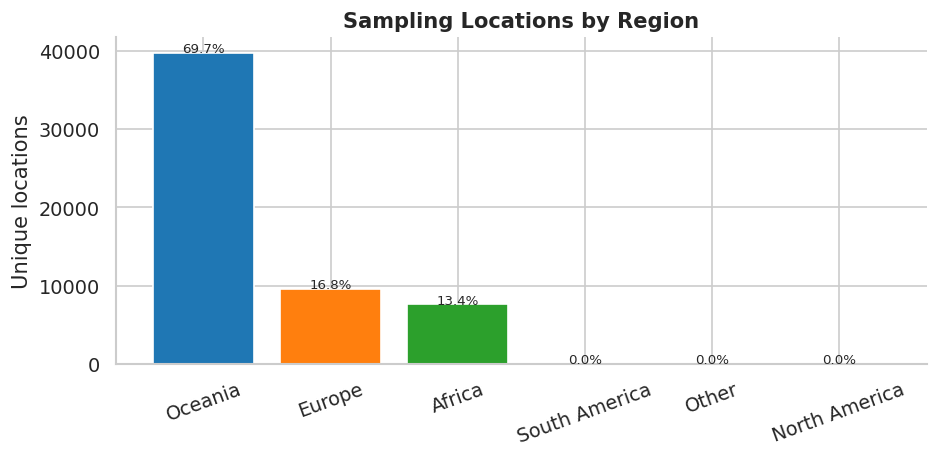

,Region,Locations,Share (%)
0,Oceania,39727,69.7
1,Europe,9584,16.8
2,Africa,7631,13.4
3,South America,27,0.0
4,Other,16,0.0
5,North America,6,0.0


In [25]:
# Geographic imbalance: locations by macro-region
def assign_region(lat, lon):
    if lat > 35 and lon > -30 and lon < 60:   return 'Europe'
    if lat > 0  and lon > 60 and lon < 150:    return 'Asia'
    if lat > 15 and lon > -140 and lon < -50:  return 'North America'
    if lat <= 15 and lat > -60 and lon > -85 and lon < -30: return 'South America'
    if lat > -40 and lat < 40 and lon > -20 and lon < 55:  return 'Africa'
    if lat < -10 and lon > 110:                return 'Oceania'
    return 'Other'

locations['region'] = locations.apply(
    lambda r: assign_region(r['lat'], r['lon']), axis=1
)

region_counts = locations['region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Locations']
region_counts['Share (%)'] = (region_counts['Locations'] / len(locations) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(region_counts['Region'], region_counts['Locations'],
              color=PALETTE[:len(region_counts)])
ax.set_ylabel('Unique locations')
ax.set_title('Sampling Locations by Region', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
for bar, pct in zip(bars, region_counts['Share (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()
region_counts

**Key takeaways - Spatial Analysis**
- Coverage is **heavily concentrated in Europe and North America**; Africa, South America, and Oceania are underrepresented relative to their agricultural land area.
- Most sampling locations cluster in temperate zones (30°-60°N), while tropical agricultural zones have sparse coverage.
- The number of properties measured per location varies widely; many locations have only 1-3 properties, limiting multi-feature ML at those points.
- For fertilizer recommendation, the geographic imbalance means predictions for sub-Saharan Africa or Southeast Asia will have high uncertainty without augmentation from regional surveys.

---
## EDA Summary - ML & Fertilizer Recommendation Readiness

| Dimension | Finding | ML Implication |
|-----------|---------|----------------|
| **Format** | Long format, ~2M rows, 24 properties | Pivot to wide format before modelling; expect high sparsity |
| **Missing data** | `sampling_date` ~52% missing; `unit` ~26% | Temporal features unreliable; impute or drop |
| **Duplicates** | Functional duplicates present | Deduplicate before train/test split to prevent leakage |
| **Depth** | Surface-biased (0-30 cm dominates) | Use `upper_depth_cm` as a feature; depth-stratified models recommended |
| **Distributions** | OC, N, EC strongly right-skewed | Log-transform skewed targets; robust scalers for features |
| **Texture** | Sand+clay+silt ≈ 100 constraint | Compositional data - use log-ratio transforms (e.g. Aitchison) |
| **Temporal** | Biased toward 1970s-80s | Models may not reflect current soil state; temporal weighting advised |
| **Spatial** | Europe/N. America dominant | Spatial cross-validation required; regional bias correction needed for tropical agriculture |
| **Sources** | 4 sources with different property coverage | Source as a categorical feature; harmonise units before combining |